# Final Modeling with Product Features

This notebook builds on the product scores created in the previous notebook. The goal is to see whether the new product-focused features improve the model and make the results easier to explain from a host guidance perspective.

Instead of only using the original listing, host, amenity, pricing, and location columns, this notebook will also include scores like host quality, amenity strength, pricing competitiveness, work-friendly score, family-friendly score, listing product score, and listing segment. These features are meant to turn the model into something closer to a host intelligence tool.

The main goal is to predict listing demand using `reviews_per_month` as a placeholder for real booking data. I will compare a few models, check whether the product features improve performance, and look at which features seem most important.

This notebook will include:

- Loading the final product feature dataset
- Selecting the final modeling features
- Creating the train/test split
- Comparing 2–3 models
- Reviewing model performance
- Looking at top demand drivers
- Translating the results into host-facing recommendations

The goal is not just to build the best model, but to understand what Airbnb hosts could actually learn from the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style='whitegrid', palette='Set2')

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

In [2]:
# loading the final dataset with product scores and listing segments
df = pd.read_csv('../data/processed/airbnb_product_modeling.csv')

df.shape

(210525, 102)

In [3]:
# edited cutt off for reviews per month to cap at 50
df = df[
    (df['reviews_per_month'] > 0) &
    (df['reviews_per_month'] <= 50)].copy()

df.shape # after demand cap

(210511, 102)

In [4]:
df.head()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,price_clean,peer_median_price,price_vs_peer,price_vs_peer_capped,pricing_competitiveness_score,pricing_competitiveness_tier,listing_product_score,listing_product_tier,listing_segment,listing_segment_name
0,108061,320564,0,0,0,2,1.0,1.0,1.0,1.0,...,100.0,98.0,0.020408,0.020408,97.959184,very high,83.391337,very high,0.0,strong_all_around
1,155305,746673,0,0,0,2,1.0,1.0,1.0,0.0,...,100.0,98.0,0.020408,0.020408,97.959184,very high,61.837337,high,3.0,standard_mid_market
2,156805,746673,0,1,0,2,1.0,1.0,2.5,0.0,...,66.0,75.0,-0.120000,-0.120000,88.000000,very high,61.674000,high,2.0,weaker_product_signal
3,197263,961396,0,1,0,2,1.0,1.0,1.0,1.0,...,45.0,75.0,-0.400000,-0.400000,60.000000,high,71.210833,high,0.0,strong_all_around
4,209068,1029919,0,0,0,4,1.0,2.0,1.0,1.0,...,100.0,124.0,-0.193548,-0.193548,80.645161,very high,81.393866,very high,0.0,strong_all_around


In [5]:
# confirming product scores and segment columns are available
product_cols = [
    'family_friendly_score',
    'work_friendly_score',
    'amenity_strength_score',
    'host_quality_score',
    'pricing_competitiveness_score',
    'listing_product_score',
    'listing_product_tier',
    'listing_segment_name']

df[product_cols].head()

,family_friendly_score,work_friendly_score,amenity_strength_score,host_quality_score,pricing_competitiveness_score,listing_product_score,listing_product_tier,listing_segment_name
0,80,60,85,81.570000,97.959184,83.391337,very high,strong_all_around
1,25,35,65,57.130000,97.959184,61.837337,high,standard_mid_market
2,25,25,56,71.640000,88.000000,61.674000,high,weaker_product_signal
3,90,50,74,76.316667,60.000000,71.210833,high,strong_all_around
4,90,85,85,75.756667,80.645161,81.393866,very high,strong_all_around


## Select Modeling Features

For this final model, I am using a cleaner recommendation-focused feature set.

I removed individual amenities that were already included inside the product scores. I also removed review score, host quality score, and listing product score to avoid double-counting or using signals that are too close to past performance.

The goal is to use features that are more useful for listing recommendations: price, capacity, location, host setup, booking settings, and broader product scores.

In [6]:
# setting the target variable for demand prediction
target = 'reviews_per_month'

# selecting cleaner recommendation-focused features
feature_cols = [
    'price_clean',
    'pricing_competitiveness_score',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'latitude',
    'longitude',
    'host_is_superhost',
    'host_response_time_ord',
    'instant_bookable',
    'family_friendly_score',
    'work_friendly_score',
    'amenity_strength_score']

# keeping only selected features and target
model_df = df[feature_cols + [target]].dropna().copy()

print('Modeling shape:', model_df.shape)
print('Feature count:', len(feature_cols))

model_df.head()

Modeling shape: (210463, 15)
Feature count: 14


,price_clean,pricing_competitiveness_score,accommodates,bedrooms,beds,bathrooms,latitude,longitude,host_is_superhost,host_response_time_ord,instant_bookable,family_friendly_score,work_friendly_score,amenity_strength_score,reviews_per_month
0,100.0,97.959184,2,1.0,1.0,1.0,35.60670,-82.55563,1.0,3.0,0,80,60,85,0.66
1,100.0,97.959184,2,1.0,1.0,1.0,35.57864,-82.59578,0.0,3.0,0,25,35,65,2.70
2,66.0,88.000000,2,1.0,1.0,2.5,35.57864,-82.59578,0.0,3.0,1,25,25,56,0.48
3,45.0,60.000000,2,1.0,1.0,1.0,35.57808,-82.63689,1.0,2.0,0,90,50,74,0.51
4,100.0,80.645161,4,1.0,2.0,1.0,35.61856,-82.55276,1.0,2.0,0,90,85,85,0.43


In [7]:
model_df.describe().T

,count,mean,std,min,25%,50%,75%,max
price_clean,210463.0,214.903617,211.989504,1.00000,95.000000,150.00000,253.000000,2000.00000
pricing_competitiveness_score,210463.0,62.581228,29.460906,0.00000,48.101266,70.00000,85.714286,100.00000
accommodates,210463.0,4.261105,2.823163,1.00000,2.000000,4.00000,6.000000,16.00000
bedrooms,210463.0,1.657161,1.178058,0.00000,1.000000,1.00000,2.000000,12.00000
beds,210463.0,2.345006,1.735482,1.00000,1.000000,2.00000,3.000000,14.00000
bathrooms,210463.0,1.472449,0.788962,0.00000,1.000000,1.00000,2.000000,8.00000
latitude,210463.0,34.682701,6.921200,18.92025,30.318993,35.63687,40.680960,47.73401
longitude,210463.0,-104.974199,25.900708,-159.71462,-118.493770,-104.96455,-80.137100,-71.07313
host_is_superhost,210463.0,0.417860,0.493208,0.00000,0.000000,0.00000,1.000000,1.00000
host_response_time_ord,210463.0,2.186337,1.443430,-1.00000,2.000000,3.00000,3.000000,3.00000


## Train/Test Split

Splitting the data into training and testing sets. The model will learn from the training data, and the test data will help check how well it performs on listings it has not seen before.

In [8]:
# setting up X and log-transformed y
X = model_df[feature_cols]
y = np.log1p(model_df[target])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((168370, 14), (42093, 14), (168370,), (42093,))

In [9]:
# checking the target distribution in train and test sets
y_train.describe(), y_test.describe()

(count    168370.000000
 mean          0.785342
 std           0.569579
 min           0.009950
 25%           0.277632
 50%           0.693147
 75%           1.217876
 max           3.908417
 Name: reviews_per_month, dtype: float64,
 count    42093.000000
 mean         0.781777
 std          0.565777
 min          0.009950
 25%          0.277632
 50%          0.693147
 75%          1.208960
 max          3.834494
 Name: reviews_per_month, dtype: float64)

The train/test split looks balanced. The mean, median, and 75th percentile for reviews per month are very similar in both sets, which means the model is being trained and tested on similar patterns. There is one outlier in the training set that's skewing the max, but the overall distribution still looks close enough to continue.

## Baseline Model

I’m starting with a simple Linear Regression model as the baseline. This gives me a basic point of comparison before trying more flexible models like Random Forest. If the more complex models do better, I can show that they added value.

In [10]:
# creating a baseline linear regression model
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [11]:
# calculating baseline model performance
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

linear_results = pd.DataFrame({
    'model': ['Linear Regression'],
    'mae': [linear_mae],
    'rmse': [linear_rmse],
    'r2': [linear_r2]})

linear_results

,model,mae,rmse,r2
0,Linear Regression,0.395713,0.489303,0.252047


## Ridge Model

Next, I’m testing a Ridge model. Ridge is similar to Linear Regression, but it adds a penalty that helps control large coefficients. This can be useful here because some of the product scores overlap with the original amenity and host features.

In [12]:
# creating a ridge model to compare against the baseline linear regression
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

In [13]:
# ridge model performance
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

# adding ridge results to the model comparison table
ridge_results = pd.DataFrame({
    'model': ['Ridge'],
    'mae': [ridge_mae],
    'rmse': [ridge_rmse],
    'r2': [ridge_r2]})

model_results = pd.concat([linear_results, ridge_results], ignore_index=True)
model_results

,model,mae,rmse,r2
0,Linear Regression,0.395713,0.489303,0.252047
1,Ridge,0.395713,0.489303,0.252047


## Random Forest Model

Random Forest can pick up more complex patterns than Linear Regression or Ridge. Since listing demand is probably shaped by a mix of price, location, amenities, host signals, and product scores, Random Forest might be a better fit.

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [15]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

# adding random forest results to comparison table
rf_results = pd.DataFrame({
    'model': ['Random Forest'],
    'mae': [rf_mae],
    'rmse': [rf_rmse],
    'r2': [rf_r2]})

model_results = pd.concat([model_results, rf_results], ignore_index=True)
model_results

,model,mae,rmse,r2
0,Linear Regression,0.395713,0.489303,0.252047
1,Ridge,0.395713,0.489303,0.252047
2,Random Forest,0.341226,0.434646,0.409812


Random Forest performs better than Linear Regression and Ridge overall. Lower MAE means the average prediction error is smaller, higher R squared means the model explains more of the variation in reviews per month.

This tells me the more flexible model is doing a better job with this dataset. Listing demand probably does not follow a simple straight-line pattern, so Random Forest seems like the better fit so far.

## Tuning RF Model


In [16]:
from sklearn.model_selection import RandomizedSearchCV

# tuning Random Forest to see if performance improves
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 0.5, 0.75]}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1)

rf_search.fit(X_train, y_train)

print('Best params:', rf_search.best_params_)
print('Best CV MAE:', -rf_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
Best CV MAE: 0.3303234617309094


In [17]:
# evaluating tuned Random Forest
tuned_rf = rf_search.best_estimator_
tuned_pred = tuned_rf.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

tuned_results = pd.DataFrame({
    'model': ['Tuned Random Forest'],
    'mae': [tuned_mae],
    'rmse': [tuned_rmse],
    'r2': [tuned_r2]})

model_results = pd.concat([model_results, tuned_results], ignore_index=True)
model_results.sort_values('r2', ascending=False)

,model,mae,rmse,r2
3,Tuned Random Forest,0.321909,0.414663,0.462832
2,Random Forest,0.341226,0.434646,0.409812
1,Ridge,0.395713,0.489303,0.252047
0,Linear Regression,0.395713,0.489303,0.252047


## Final Model Selection

The tuned Random Forest performed best overall, so I am using it as the final model.

It uses a clean recommendation-focused feature set. I removed raw amenity columns that were already included in the product scores, and I removed review score, host quality score, and listing product score to avoid double-counting.

The model is predicting log-transformed reviews per month, so the scores should be read as model performance on the log scale. Later, I convert predictions back to normal reviews per month so the results are easier to understand.

In [18]:
# setting the tuned random forest as the final model
final_model = tuned_rf
final_pred_log = tuned_pred
final_feature_cols = feature_cols

# converting predictions and actual values back to normal reviews per month
final_pred = np.expm1(final_pred_log)
actual_reviews = np.expm1(y_test)

# creating a dataframe to compare actual vs predicted demand
prediction_results = pd.DataFrame({
    'actual_reviews_per_month': actual_reviews,
    'predicted_reviews_per_month': final_pred})

prediction_results['prediction_error'] = (
    prediction_results['actual_reviews_per_month'] -
    prediction_results['predicted_reviews_per_month'])

prediction_results.head()

,actual_reviews_per_month,predicted_reviews_per_month,prediction_error
145793,2.57,1.085619,1.484381
152263,0.72,0.614207,0.105793
205230,2.00,1.009545,0.990455
134181,0.36,0.213376,0.146624
115667,0.82,1.339736,-0.519736


In [19]:
# checking final model error on the original reviews per month scale
final_mae_original = mean_absolute_error(
    prediction_results['actual_reviews_per_month'],
    prediction_results['predicted_reviews_per_month'])

final_rmse_original = np.sqrt(mean_squared_error(
    prediction_results['actual_reviews_per_month'],
    prediction_results['predicted_reviews_per_month']))

print('Final MAE on original scale:', round(final_mae_original, 3))
print('Final RMSE on original scale:', round(final_rmse_original, 3))

Final MAE on original scale: 0.882
Final RMSE on original scale: 1.439


## Feature Importance

Checking which features the tuned Random Forest used most.

It shows which features helped the model make predictions since RF can pick up nonlinear patterns.

In [20]:
# creating feature importance dataframe from the tuned random forest model
final_importance = pd.DataFrame({
    'feature': final_feature_cols,
    'importance': final_model.feature_importances_})

final_importance = final_importance.sort_values('importance', ascending=False)

final_importance

,feature,importance
9,host_response_time_ord,0.148764
7,longitude,0.131893
6,latitude,0.122468
0,price_clean,0.115199
1,pricing_competitiveness_score,0.091842
13,amenity_strength_score,0.087676
12,work_friendly_score,0.070019
8,host_is_superhost,0.059739
11,family_friendly_score,0.056522
2,accommodates,0.043346


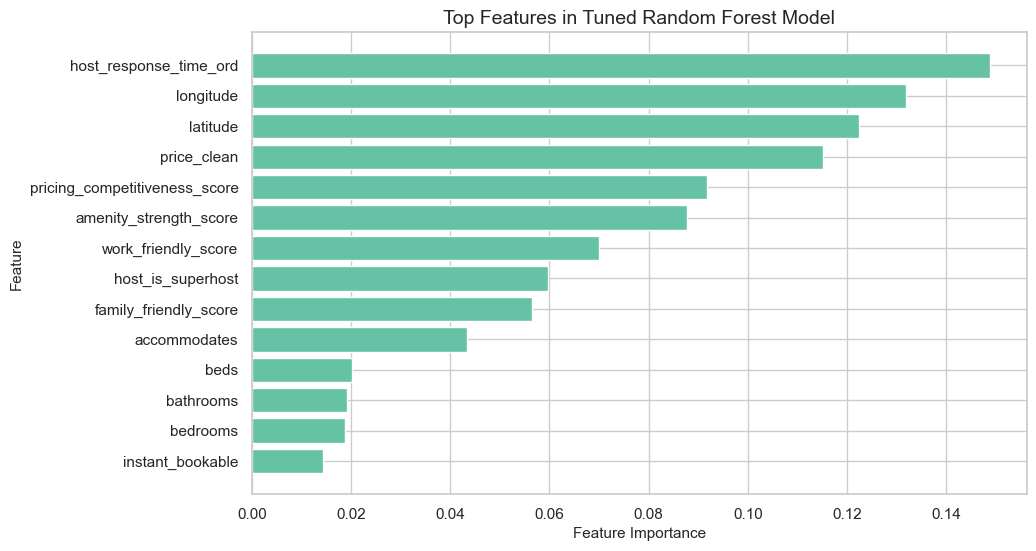

In [21]:
top_final_features = final_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_final_features['feature'], top_final_features['importance'])
plt.gca().invert_yaxis()
plt.title('Top Features in Tuned Random Forest Model')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

## Overfitting Check

Seeing how the model performs on test vs training data and making sure it didn't just memorize the training set.

   small gap: normal

   large gap: warning sign

In [22]:
# checking train vs test performance for the final tuned model
train_pred_log = final_model.predict(X_train)
test_pred_log = final_model.predict(X_test)

train_mae = mean_absolute_error(y_train, train_pred_log)
test_mae = mean_absolute_error(y_test, test_pred_log)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred_log))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_log))

train_r2 = r2_score(y_train, train_pred_log)
test_r2 = r2_score(y_test, test_pred_log)

overfit_check = pd.DataFrame({
    'dataset': ['train', 'test'],
    'mae': [train_mae, test_mae],
    'rmse': [train_rmse, test_rmse],
    'r2': [train_r2, test_r2]})

overfit_check

,dataset,mae,rmse,r2
0,train,0.158165,0.209153,0.865159
1,test,0.321909,0.414663,0.462832


### Overfitting Check Interpretation

RF model shows some overfitting. The model performs much better on the training data than the test data, especially when comparing R sqaured.

The test score is still useful, but the data itself is noisy (multiple reviews for the same stay, no datetimes for listing creation, etc). Other missing information: seasonality, listing photos, guest preferences, and actual booking availability.

The main takeaway is that this model is better for comparing listing scenarios than making exact predictions. It can help show which listing setup looks stronger in a specific location, but the results should be treated as directional.

## Actual vs Predicted Demand

Since the model was trained on log-transformed reviews per month, I converted the predictions back to the original reviews per month scale. This makes the results easier to understand.

If the points are spread out, then the model is missing some of the variation in demand.

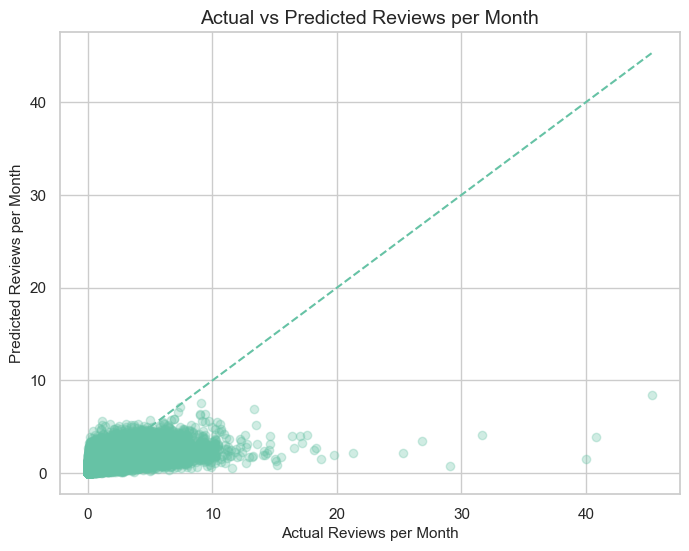

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_results['actual_reviews_per_month'],
    prediction_results['predicted_reviews_per_month'],
    alpha=0.3)

max_value = max(
    prediction_results['actual_reviews_per_month'].max(),
    prediction_results['predicted_reviews_per_month'].max())

plt.plot([0, max_value], [0, max_value], linestyle='--')

plt.title('Actual vs Predicted Reviews per Month')
plt.xlabel('Actual Reviews per Month')
plt.ylabel('Predicted Reviews per Month')
plt.show()

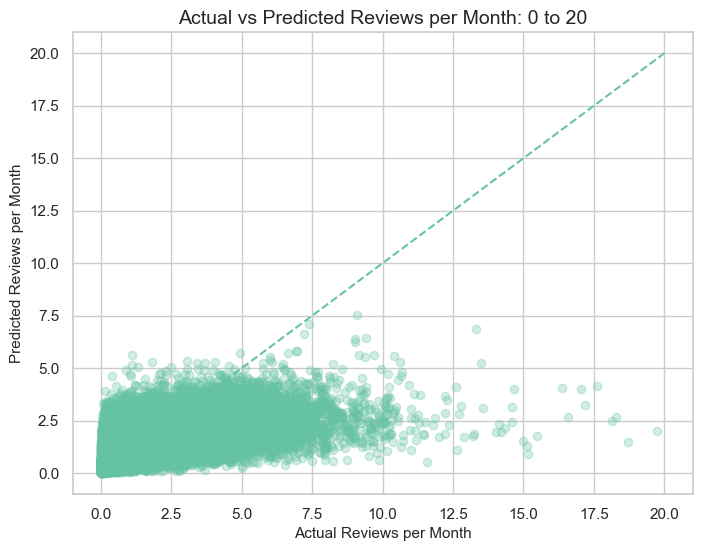

In [24]:
# zooming in on the normal demand range so the pattern is easier to read
plot_df = prediction_results[
    prediction_results['actual_reviews_per_month'] <= 20].copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df['actual_reviews_per_month'],
    plot_df['predicted_reviews_per_month'],
    alpha=0.3)

plt.plot([0, 20], [0, 20], linestyle='--')

plt.title('Actual vs Predicted Reviews per Month: 0 to 20')
plt.xlabel('Actual Reviews per Month')
plt.ylabel('Predicted Reviews per Month')
plt.show()

### Actual vs Predicted Interpretation

The model does well with listings in low to moderate reviews per month, but it under predicts high-demand listing. I would be curious to see if adjusting the reviews per month to 31 (most days in a month), makes a difference in prediction. 

Some listings may perform unusually well because of things the model does not fully capture, like photos, design quality, seasonality, events, exact neighborhood appeal, or listing age.

For this project, I would use the model to compare listing scenarios and spot stronger patterns, not to predict exact reviews per month.

## Prediction Error by Demand Tier

Checking to see if the model works better for different demand tiers.

In [25]:
# creating demand tiers based on actual reviews per month
prediction_results['demand_tier'] = pd.cut(
    prediction_results['actual_reviews_per_month'],
    bins=[0, 1, 3, 6, 10, 50],
    labels=['very low', 'low', 'medium', 'high', 'very high'],
    include_lowest=True)

# summarizing model error by demand tier
error_by_tier = (
    prediction_results
    .groupby('demand_tier', observed=False)
    .agg(
        listing_count=('actual_reviews_per_month', 'count'),
        avg_actual_reviews=('actual_reviews_per_month', 'mean'),
        avg_predicted_reviews=('predicted_reviews_per_month', 'mean'),
        avg_error=('prediction_error', 'mean'),
        mae=('prediction_error', lambda x: np.mean(np.abs(x))))
    .reset_index())

error_by_tier

,demand_tier,listing_count,avg_actual_reviews,avg_predicted_reviews,avg_error,mae
0,very low,21229,0.391922,0.859069,-0.467146,0.518995
1,low,13738,1.888665,1.642630,0.246035,0.649389
2,medium,6085,4.066330,2.173129,1.893201,1.914263
3,high,934,7.259550,2.567957,4.691594,4.691594
4,very high,107,13.559626,2.774783,10.784844,10.784844


In [26]:
plt.figure(figsize=(9, 5))

x = np.arange(len(error_by_tier))
width = 0.35

plt.bar(
    x - width / 2,
    error_by_tier['avg_actual_reviews'],
    width,
    label='Actual',
    color=set2_colors[0])

plt.bar(
    x + width / 2,
    error_by_tier['avg_predicted_reviews'],
    width,
    label='Predicted',
    color=set2_colors[1])

plt.xticks(
    x,
    error_by_tier['demand_tier'].astype(str),
    rotation=0)

plt.title('Average Actual vs Predicted Reviews per Month by Demand Tier')
plt.xlabel('Demand Tier')
plt.ylabel('Reviews per Month')
plt.legend(title='Value Type')
plt.tight_layout()
plt.show()

NameError: name 'set2_colors' is not defined

<Figure size 900x500 with 0 Axes>

## Save Final Model

The tuned Random Forest is the final model for the location-based recommendation notebook.

Saving model and extracted features since the next notebook needs to create listing scenarios with the same columns the model was trained on.

In [ ]:
import os
import joblib

# saving final recommendation model and feature list
os.makedirs('../models', exist_ok=True)

joblib.dump(final_model, '../models/rf_location_recommendation_model.pkl')
joblib.dump(final_feature_cols, '../models/rf_location_recommendation_features.pkl')

print('Saved final recommendation model')
print('Saved feature list:', len(final_feature_cols))

In [ ]:
# checking saved feature list
saved_features = joblib.load('../models/rf_location_recommendation_features.pkl')

saved_features

In [27]:
# calculating original-scale R2 from final prediction results
final_r2_original = r2_score(
    prediction_results['actual_reviews_per_month'],
    prediction_results['predicted_reviews_per_month'])

print('Final R2 on original scale:', round(final_r2_original, 3))

Final R2 on original scale: 0.328


In [28]:
# creating a readable model metrics file for submission
model_metrics_path = '../models/final_model_metrics_summary.txt'

with open(model_metrics_path, 'w') as f:
    f.write('Final Model Metrics Summary\n')
    f.write('===========================\n\n')

    f.write('Project: Airbnb Demand + Location Recommendation\n')
    f.write('Final model: Tuned Random Forest Regressor\n')
    f.write('Target variable: np.log1p(reviews_per_month)\n')
    f.write('Prediction output: converted back with np.expm1()\n\n')

    f.write('Performance on Log Scale\n')
    f.write('------------------------\n')
    f.write(f'R2 Score: {tuned_r2:.3f}\n')
    f.write(f'MAE: {tuned_mae:.3f}\n')
    f.write(f'RMSE: {tuned_rmse:.3f}\n\n')

    f.write('Performance on Original Reviews per Month Scale\n')
    f.write('-----------------------------------------------\n')
    f.write(f'R2 Score: {final_r2_original:.3f}\n')
    f.write(f'MAE: {final_mae_original:.3f}\n')
    f.write(f'RMSE: {final_rmse_original:.3f}\n\n')

    f.write('Final Model Features\n')
    f.write('--------------------\n')
    for feature in final_feature_cols:
        f.write(f'- {feature}\n')

    f.write('\nFinal Model Hyperparameters\n')
    f.write('---------------------------\n')
    for param, value in final_model.get_params().items():
        f.write(f'{param}: {value}\n')

    f.write('\nSaved Files\n')
    f.write('-----------\n')
    f.write('Model file: ../models/rf_location_recommendation_model.pkl\n')
    f.write('Feature list file: ../models/rf_location_recommendation_features.pkl\n')

print('Saved model metrics summary to:', model_metrics_path)

Saved model metrics summary to: ../models/final_model_metrics_summary.txt
